# Detailed EDA — Company Financials Dataset

## Objective

Perform detailed exploratory analysis of the financial information supplied under the Company Financials label after the [dataset inventory](01_dataset_inventory.ipynb). The intended questions concern company coverage, distributions, differences between companies, changes across periods, relationships between metrics, missingness, extreme observations, and potential analytical/anomaly-detection uses.

**Scope correction from the inventory:** the file contains sales observations, not an identified company financial-statement panel. No company name or identifier is supplied. Company coverage, company size, cross-company performance, and within-company growth therefore cannot be measured. Supported analyses use segment, country, product, discount band, and monthly labels without treating them as companies. Assets, liabilities, equity, and cash are not invented.

**Preservation:** raw files and `raw_df` remain unchanged. Numeric parsing, date parsing, ratios, and descriptive candidate flags exist only in separate notebook objects. No imputation, row/column removal, permanent cleaning, winsorization, stored-data normalization, FX conversion, production features, ML training, or application implementation occurs.

**Interpretation limits:** provenance, currency, entity scope, exact aggregation grain, and source measure definitions remain unconfirmed. `$` does not identify a currency; Country does not identify currency or company. Pooled magnitude summaries and cross-record medians describe recorded numbers, not confirmed comparable monetary values. Arithmetic relationships can support hypotheses but cannot establish a common currency. Extreme observations are candidates for investigation, not automatically errors or fraud.

## 1. Setup and Data Loading

Use the same raw CSV as the inventory and the existing project environment. Matplotlib is already installed. Exact original headers, whitespace, and string values are retained. Snapshots and hashes protect both earlier notebooks and all raw files.

In [1]:
from pathlib import Path
import hashlib
import io
import re
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

project_root = Path.cwd() if (Path.cwd()/"data/raw").exists() else Path.cwd().parent
raw_path = project_root/"data/raw/Company Financials Dataset/Financials.csv"
protected = sorted(p for p in (project_root/"data/raw").rglob("*") if p.is_file()) + [project_root/"notebooks/01_dataset_inventory.ipynb", project_root/"notebooks/02_eda_receiver_general.ipynb"]
original_hashes = {str(p):hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
raw_df = pd.read_csv(raw_path)
raw_snapshot = raw_df.copy(deep=True)
expected_columns = ['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ', ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ', '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number', ' Month Name ', 'Year']
assert raw_df.shape == (700,16)
assert raw_df.columns.tolist() == expected_columns
measure_map = {"units":" Units Sold ","manufacturing_price":" Manufacturing Price ","sale_price":" Sale Price ","gross_sales":" Gross Sales ","discounts":" Discounts ","sales":"  Sales ","cogs":" COGS ","profit":" Profit "}
plt.rcParams.update({"axes.titlesize":11,"axes.labelsize":10})
pd.set_option("display.max_columns",20)
pd.set_option("display.max_rows",65)
pd.set_option("display.max_colwidth",None)

def show_figure(fig):
    """Embed a static plot without requiring a GUI or additional plotting package."""
    fig.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer,format="png",dpi=120,bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print("Source:",raw_path.relative_to(project_root))
print("Shape:",raw_df.shape,"Exact headers validated:",len(expected_columns))
print("Environment:",sys.version.split()[0],"pandas",pd.__version__,"matplotlib",matplotlib.__version__)
print("Raw SHA-256:",original_hashes[str(raw_path)])

Source: data/raw/Company Financials Dataset/Financials.csv
Shape: (700, 16) Exact headers validated: 16
Environment: 3.14.7 pandas 3.0.5 matplotlib 3.11.2
Raw SHA-256: 86b856a1d4453fc1fe76afbc7dff8ed90aa6f0144a841c8daf5cd8934bca6d51


## 2. EDA Baseline Validation

Validate the critical inventory facts without repeating the inventory. The price-dependent six-field key remains an empirical candidate, not a stable business identifier. Date parsing explicitly uses day/month/year because all strings agree with the separate Month Number and Year labels. This does not establish fiscal-year boundaries or actual transaction dates.

In [2]:
dimension_key = ["Segment","Country"," Product "," Discount Band ","Date"]
candidate_key = dimension_key + [" Sale Price "]
dates = pd.to_datetime(raw_df.Date,format="%d/%m/%Y",errors="coerce")
assert dates.notna().all()
assert dates.dt.month.eq(raw_df["Month Number"]).all()
assert dates.dt.year.eq(raw_df.Year).all()
assert dates.dt.day.eq(1).all()
periods = dates.dt.to_period("M")
baseline = pd.Series({"rows":len(raw_df),"columns":raw_df.shape[1],"complete_duplicates":int(raw_df.duplicated().sum()),"raw_missing_cells":int(raw_df.isna().sum().sum()),"five_dimension_repetitions":int(raw_df.duplicated(dimension_key).sum()),"candidate_key_repetitions":int(raw_df.duplicated(candidate_key).sum()),"candidate_key_missing_rows":int(raw_df[candidate_key].isna().any(axis=1).sum()),"date_parse_failures":int(dates.isna().sum()),"monthly_periods":periods.nunique()})
assert baseline.tolist() == [700,16,0,0,12,0,0,0,16]
assert dates.min() == pd.Timestamp("2013-09-01") and dates.max() == pd.Timestamp("2014-12-01")
display(baseline.to_frame("observed"))
print("Company identifiers: none among the 16 inventoried columns; company count is unknown, not zero.")

,observed
rows,700
columns,16
complete_duplicates,0
raw_missing_cells,0
five_dimension_repetitions,12
candidate_key_repetitions,0
candidate_key_missing_rows,0
date_parse_failures,0
monthly_periods,16


Company identifiers: none among the 16 inventoried columns; company count is unknown, not zero.


## 3. Financial Measure Parsing Validation

All eight measures are stored as formatted text. Reuse the inventory's explicitly stated parsing conventions: decimal point and two fractional digits; validated three-digit or Indian-style comma grouping; optional matched parentheses interpreted as negatives for this EDA; `$` and surrounding whitespace treated as formatting, not currency identification. Parentheses/sign semantics still require source confirmation.

A strict full-string grammar is applied separately to each named measure. No unrestricted removal of nonnumeric characters is allowed. Dollar-dash tokens remain **unresolved placeholders**, not zeros. Unexpected formats and original nulls receive distinct statuses. Unavailable values become NaN **only in the temporary numeric table**. No value is inferred from another measure. Percent signs, unsupported symbols, or malformed strings would be reported as unrecognized rather than guessed.

In [3]:
amount_pattern = re.compile(r"\s*\$\s*(?P<open>\()?\s*(?P<amount>(?:\d{1,3}(?:,\d{3})+|\d{1,2}(?:,\d{2})*,\d{3}|\d+)\.\d{2})\s*(?P<close>\))?\s*")

def parse_for_eda(value):
    if pd.isna(value): return np.nan,"source_missing"
    if re.fullmatch(r"\s*\$-\s*",value): return np.nan,"unresolved_dash"
    match = amount_pattern.fullmatch(value)
    if match is None or bool(match["open"]) != bool(match["close"]): return np.nan,"unrecognized_format"
    magnitude = float(match["amount"].replace(",",""))
    return (-magnitude if match["open"] else magnitude),"parsed"

numeric = pd.DataFrame(index=raw_df.index)
parse_status = pd.DataFrame(index=raw_df.index)
parsing_rows=[]
for alias,source in measure_map.items():
    parsed = raw_df[source].map(parse_for_eda)
    numeric[alias] = parsed.map(lambda pair:pair[0])
    parse_status[alias] = parsed.map(lambda pair:pair[1])
    statuses = parse_status[alias]
    parsing_rows.append({"measure":alias,"original_dtype":str(raw_df[source].dtype),"raw_samples":repr(raw_df[source].head(2).tolist()),"populated":int(raw_df[source].notna().sum()),"successful":int(statuses.eq("parsed").sum()),"unsuccessful_populated":int((raw_df[source].notna() & statuses.ne("parsed")).sum()),"unresolved_dash":int(statuses.eq("unresolved_dash").sum()),"unrecognized_format":int(statuses.eq("unrecognized_format").sum()),"numeric_coverage_percent":numeric[alias].notna().mean()*100})
parsing_report=pd.DataFrame(parsing_rows).set_index("measure")
display(parsing_report)
format_report=pd.DataFrame({alias:{"dollar_symbol":raw_df[source].str.contains("$",regex=False).sum(),"comma":raw_df[source].str.contains(",",regex=False).sum(),"parentheses":raw_df[source].str.contains("(",regex=False).sum(),"percent_symbol":raw_df[source].str.contains("%",regex=False).sum(),"other_currency_symbol":raw_df[source].str.contains(r"[€£¥₹]").sum()} for alias,source in measure_map.items()}).T
display(format_report)
print("Unsuccessful raw representations:")
for alias,source in measure_map.items():
    failed=parse_status[alias].ne("parsed")
    if failed.any():
        print(alias); display(raw_df.loc[failed,source].value_counts(dropna=False).to_frame("records"))
assert parsing_report.unrecognized_format.sum()==0
assert numeric.count().to_dict()=={"units":700,"manufacturing_price":700,"sale_price":700,"gross_sales":700,"discounts":647,"sales":700,"cogs":700,"profit":695}
eda = pd.DataFrame({"segment":raw_df.Segment,"country":raw_df.Country,"product":raw_df[" Product "],"discount_band":raw_df[" Discount Band "],"period":periods,"date":dates}).join(numeric)
print("Original whitespace remains in categorical values and source headers; aliases exist only in EDA objects.")

,original_dtype,raw_samples,populated,successful,unsuccessful_populated,unresolved_dash,unrecognized_format,numeric_coverage_percent
measure,,,,,,,,
units,str,"[' $1,618.50 ', ' $1,321.00 ']",700,700,0,0,0,100.000000
manufacturing_price,str,"[' $3.00 ', ' $3.00 ']",700,700,0,0,0,100.000000
sale_price,str,"[' $20.00 ', ' $20.00 ']",700,700,0,0,0,100.000000
gross_sales,str,"[' $32,370.00 ', ' $26,420.00 ']",700,700,0,0,0,100.000000
discounts,str,"[' $- ', ' $- ']",700,647,53,53,0,92.428571
sales,str,"[' $32,370.00 ', ' $26,420.00 ']",700,700,0,0,0,100.000000
cogs,str,"[' $16,185.00 ', ' $13,210.00 ']",700,700,0,0,0,100.000000
profit,str,"[' $16,185.00 ', ' $13,210.00 ']",700,695,5,5,0,99.285714


,dollar_symbol,comma,parentheses,percent_symbol,other_currency_symbol
units,700,499,0,0,0
manufacturing_price,700,0,0,0,0
sale_price,700,0,0,0,0
gross_sales,700,700,0,0,0
discounts,700,492,0,0,0
sales,700,700,0,0,0
cogs,700,699,0,0,0
profit,700,670,58,0,0


Unsuccessful raw representations:
discounts


,records
Discounts,
$-,53


profit


,records
Profit,
$-,5


Original whitespace remains in categorical values and source headers; aliases exist only in EDA objects.


## 4. Company Coverage

**Not identifiable:** there is no company ID or company name. Number of companies, records/periods per company, company continuity, and companies with few observations cannot be determined. The following table explicitly describes observed **categories**, not substitute companies. Segment labels are not established industry classifications.

In [4]:
category_coverage={}
for field in ["segment","country","product","discount_band"]:
    table=eda.groupby(field,dropna=False).agg(records=("period","size"),periods=("period","nunique"),first_period=("period","min"),last_period=("period","max"))
    category_coverage[field]=table
    print(field);display(table)
print("No company identifiers are created from these categories.")

segment


,records,periods,first_period,last_period
segment,,,,
Channel Partners,100,16,2013-09,2014-12
Enterprise,100,16,2013-09,2014-12
Government,300,16,2013-09,2014-12
Midmarket,100,16,2013-09,2014-12
Small Business,100,16,2013-09,2014-12


country


,records,periods,first_period,last_period
country,,,,
Canada,140,16,2013-09,2014-12
France,140,16,2013-09,2014-12
Germany,140,16,2013-09,2014-12
Mexico,140,16,2013-09,2014-12
United States of America,140,16,2013-09,2014-12


product


,records,periods,first_period,last_period
product,,,,
Amarilla,94,16,2013-09,2014-12
Carretera,93,16,2013-09,2014-12
Montana,93,16,2013-09,2014-12
Paseo,202,16,2013-09,2014-12
VTT,109,16,2013-09,2014-12
Velo,109,16,2013-09,2014-12


discount_band


,records,periods,first_period,last_period
discount_band,,,,
High,245,16,2013-09,2014-12
Low,160,16,2013-09,2014-12
Medium,242,16,2013-09,2014-12
None,53,14,2013-09,2014-12


No company identifiers are created from these categories.


## 5. Temporal Coverage

Existing date/month/year agreement supports **monthly labels**, not individual sale dates. Date labels span September 2013–December 2014. No fiscal-year equivalence is assumed. Check complete-period coverage at the dataset and category-combination level: full coverage of individual categories does not imply a balanced panel of their combinations.

,records
period,
2013-09,35
2013-10,70
2013-11,35
2013-12,35
2014-01,35
2014-02,35
2014-03,35
2014-04,35
2014-05,35


Observed range: 2013-09 to 2014-12 Periods: 16 Missing inside range: []
Coverage across observed segment/country/product combinations:


,periods_per_combination
count,150.000000
mean,4.400000
std,2.937835
min,2.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,16.000000


Combinations with all 16 periods: 2 of 150
Five shortest observed combination histories:


periods
segment          country product           
Channel Partners Canada  Amarilla         2
                         Montana          2
                         VTT              2
                         Velo             2
                 France  Montana          2

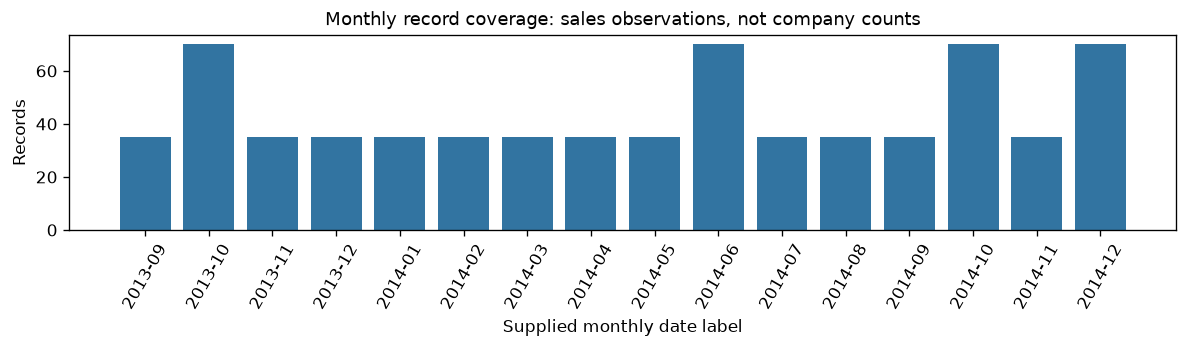

In [5]:
observed_periods=pd.PeriodIndex(sorted(periods.unique()),freq="M")
expected_periods=pd.period_range(observed_periods.min(),observed_periods.max(),freq="M")
missing_periods=expected_periods.difference(observed_periods)
monthly_counts=eda.groupby("period").size().rename("records")
display(monthly_counts.to_frame())
print("Observed range:",observed_periods.min(),"to",observed_periods.max(),"Periods:",len(observed_periods),"Missing inside range:",missing_periods.tolist())
combination_periods=eda.groupby(["segment","country","product"]).period.nunique()
print("Coverage across observed segment/country/product combinations:")
display(combination_periods.describe().to_frame("periods_per_combination"))
print("Combinations with all 16 periods:",int(combination_periods.eq(16).sum()),"of",len(combination_periods))
print("Five shortest observed combination histories:");display(combination_periods.nsmallest(5).to_frame("periods"))
fig,ax=plt.subplots(figsize=(10,3))
ax.bar(monthly_counts.index.astype(str),monthly_counts.values,color="#3274a1")
ax.set(title="Monthly record coverage: sales observations, not company counts",xlabel="Supplied monthly date label",ylabel="Records")
ax.tick_params(axis="x",rotation=60);show_figure(fig)

**Observed coverage:** individual countries, segments, and products each span all 16 monthly labels, but only **2 of 150** segment/country/product combinations do so. Combination histories range from **2 to 16 periods**, with median **4**. Month counts are 35 or 70. This is not a balanced panel of category combinations, much less an identified company panel. Absence of a combination in a month is not proved to be missing business activity.

## 6. Financial Measure Distributions

Analyze quantity, manufacturing price, sale price, gross sales, discounts, sales, COGS, and profit only. All numeric statistics are conditional on the parsing conventions; numeric coverage differs by measure. The tables and charts describe **unconfirmed source-unit magnitudes** and do not establish currency-comparable financial scales. Price distributions are discrete; prices are not added together.

The Sales log display uses positive amounts only; Profit uses a symmetric logarithmic axis that preserves negative values. This changes display coordinates, not values. Percentiles are interpolated descriptively; no observations are removed.

In [6]:
distribution=numeric.describe(percentiles=[.01,.05,.25,.5,.75,.9,.95,.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,skewness,negative_count,numeric_zero_count
units,700.0,1608.294286,867.427859,200.00,256.880,344.95,905.00,1542.50,2229.125,2761.2,2935.95,3875.205,4492.5,0.436154,0,0
manufacturing_price,700.0,96.477143,108.602612,3.00,3.000,3.00,5.00,10.00,250.000,260.0,260.00,260.000,260.0,0.592584,0,0
sale_price,700.0,118.428571,136.775515,7.00,7.000,7.00,12.00,20.00,300.000,350.0,350.00,350.000,350.0,0.771282,0,0
gross_sales,700.0,182759.426429,254262.284378,1799.00,2520.000,5193.05,17391.75,37980.00,279025.000,600645.0,754250.00,1006950.000,1207500.0,1.673922,0,0
discounts,647.0,14227.586198,23562.833079,18.41,92.334,274.08,1061.00,3108.00,18809.250,42845.1,64813.95,110350.350,149677.5,2.566287,0,0
sales,700.0,169609.071843,236726.346899,1655.08,2293.200,4535.65,15928.00,35540.20,261077.500,563733.6,683574.75,978321.750,1159200.0,1.696295,0,0
cogs,700.0,145475.211429,203865.506118,918.00,1230.000,2449.50,7490.00,22506.25,245607.500,469550.0,608643.75,748022.300,950625.0,1.549048,0,0
profit,695.0,24307.485309,42865.115657,-40617.50,-24260.875,-7964.25,2929.32,9297.00,22777.500,79418.1,117208.60,236716.000,262200.0,2.700922,58,0


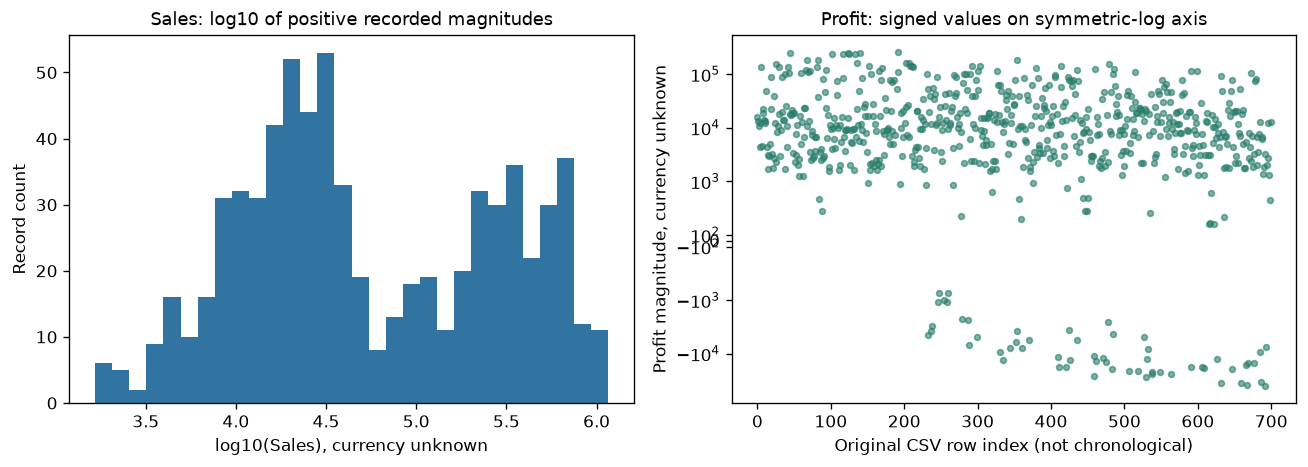

**Observation:** Sales mean 169,609.07 versus median 35,540.20; skewness 1.696. Profit ranges from -40,617.50 to 262,200.00, with 58 negative values under the parentheses convention. Discounts and Profit statistics exclude 53 and 5 unresolved tokens, respectively. Extremes are not automatically errors.

In [7]:
distribution["skewness"]=numeric.skew()
distribution["negative_count"]=numeric.lt(0).sum()
distribution["numeric_zero_count"]=numeric.eq(0).sum()
display(distribution)
fig,axes=plt.subplots(1,2,figsize=(11,4))
positive_sales=numeric.sales[numeric.sales>0]
axes[0].hist(np.log10(positive_sales),bins=30,color="#3274a1")
axes[0].set(title="Sales: log10 of positive recorded magnitudes",xlabel="log10(Sales), currency unknown",ylabel="Record count")
axes[1].scatter(numeric.profit.index,numeric.profit,s=12,alpha=.6,color="#287d6c")
axes[1].set_yscale("symlog",linthresh=1000)
axes[1].set(title="Profit: signed values on symmetric-log axis",xlabel="Original CSV row index (not chronological)",ylabel="Profit magnitude, currency unknown")
show_figure(fig)
display(Markdown(f"**Observation:** Sales mean {numeric.sales.mean():,.2f} versus median {numeric.sales.median():,.2f}; skewness {numeric.sales.skew():.3f}. Profit ranges from {numeric.profit.min():,.2f} to {numeric.profit.max():,.2f}, with {numeric.profit.lt(0).sum()} negative values under the parentheses convention. Discounts and Profit statistics exclude {numeric.discounts.isna().sum()} and {numeric.profit.isna().sum()} unresolved tokens, respectively. Extremes are not automatically errors."))

## 7. Company Size and Scale

Company size cannot be measured: no company identity, assets, equity, or documented company revenue exists. Instead, inspect how **recorded Sales magnitudes** vary across observations and categories. Shares below are arithmetic shares of numbers as supplied, not confirmed revenue shares: cross-record currency comparability is unknown. No company is ranked, and no normalization is performed.

In [8]:
scale_rows=[]
for field in ["segment","country","product"]:
    table=eda.groupby(field).sales.agg(records="size",median="median",maximum="max",recorded_numeric_sum="sum")
    table["arithmetic_share_percent"]=table.recorded_numeric_sum/numeric.sales.sum()*100
    print(field);display(table.sort_values("recorded_numeric_sum",ascending=False))
    scale_rows.append({"category":field,"largest_category_share_of_numeric_sum":table.arithmetic_share_percent.max(),"largest_category":table.arithmetic_share_percent.idxmax()})
scale_summary=pd.DataFrame(scale_rows)
record_top1_share=numeric.sales.nlargest(7).sum()/numeric.sales.sum()*100
print("Largest 7 records (1% of rows), share of recorded Sales numeric sum:",record_top1_share)
print("No economic concentration or large-company conclusion follows without entity/currency confirmation.")

segment


,records,median,maximum,recorded_numeric_sum,arithmetic_share_percent
segment,,,,,
Government,300,27286.875,1159200.00,52504260.68,44.222921
Small Business,100,373755.000,1038082.50,42427918.50,35.735890
Enterprise,100,185389.375,527437.50,19611694.38,16.518401
Midmarket,100,24349.650,53594.10,2381883.09,2.006196
Channel Partners,100,18498.960,42997.68,1800593.64,1.516591


country


,records,median,maximum,recorded_numeric_sum,arithmetic_share_percent
country,,,,,
United States of America,140,32316.19,1159200.0,25029830.18,21.081950
Canada,140,37180.70,1038082.5,24887654.89,20.962200
France,140,37044.30,962500.0,24354172.29,20.512862
Germany,140,28299.75,1017338.0,23505340.82,19.797914
Mexico,140,36287.10,848172.5,20949352.11,17.645074


product


,records,median,maximum,recorded_numeric_sum,arithmetic_share_percent
product,,,,,
Paseo,202,32419.2,1159200.0,33011143.96,27.804395
VTT,109,50597.0,986811.0,20511921.02,17.276637
Velo,109,43125.0,1035625.5,18250059.47,15.371532
Amarilla,94,35167.8,1017338.0,17747116.07,14.947917
Montana,93,32877.9,1038082.5,15390801.88,12.963257
Carretera,93,34112.4,978236.0,13815307.89,11.636261


Largest 7 records (1% of rows), share of recorded Sales numeric sum: 6.0990723477245705
No economic concentration or large-company conclusion follows without entity/currency confirmation.


**Observed scale differences:** Government contributes **44.22%** and Small Business **35.74%** of the arithmetic Sales sum. The seven largest Sales records contribute **6.10%**. These quantify recorded-number concentration only; unknown currencies and entity scope prevent interpreting them as company size or economic revenue shares.

## 8. Financial Performance Across Companies

Cross-company performance is unsupported. The category profiles below compare medians and ranges of recorded measures by segment and product, with coverage and negative-Profit counts shown. They are not ratings of companies and do not establish cross-currency purchasing power or performance.

,records,median_sales,median_cogs,median_profit,profit_available,negative_profit,median_sale_price
segment,,,,,,,
Channel Partners,100,18498.960,4971.0,13242.96,100,0,12.0
Enterprise,100,185389.375,190740.0,-3727.50,95,58,125.0
Government,300,27286.875,15330.0,12360.80,300,0,20.0
Midmarket,100,24349.650,18185.0,6665.80,100,0,15.0
Small Business,100,373755.000,342250.0,36592.50,100,0,300.0


,records,median_sales,median_profit,profit_available
product,,,,
Amarilla,94,35167.8,11055.00,93
Carretera,93,34112.4,9200.64,93
Montana,93,32877.9,9373.20,92
Paseo,202,32419.2,9200.64,199
VTT,109,50597.0,11635.60,109
Velo,109,43125.0,6580.80,109


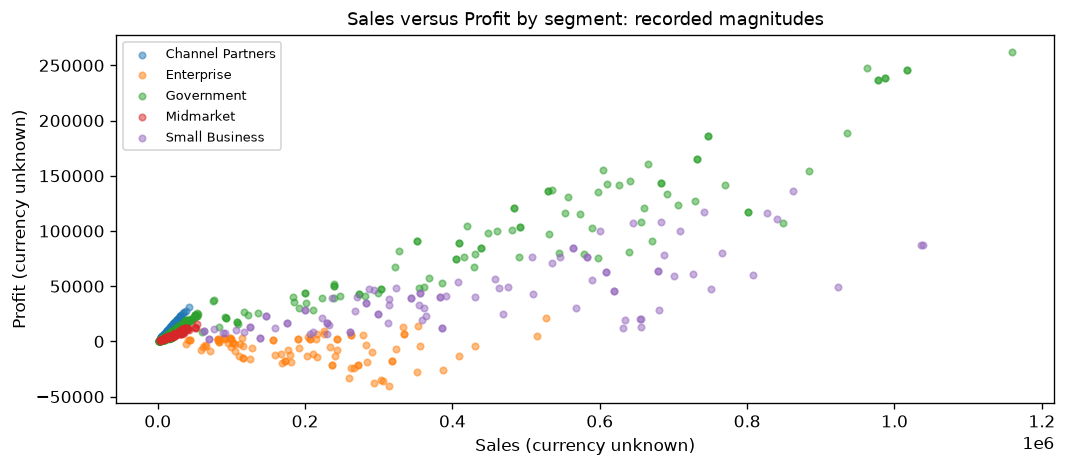

In [9]:
segment_profile=eda.groupby("segment").agg(records=("sales","size"),median_sales=("sales","median"),median_cogs=("cogs","median"),median_profit=("profit","median"),profit_available=("profit","count"),negative_profit=("profit",lambda s:s.lt(0).sum()),median_sale_price=("sale_price","median"))
product_profile=eda.groupby("product").agg(records=("sales","size"),median_sales=("sales","median"),median_profit=("profit","median"),profit_available=("profit","count"))
display(segment_profile);display(product_profile)
fig,ax=plt.subplots(figsize=(9,4))
for segment,group in eda.groupby("segment"):
    ax.scatter(group.sales,group.profit,s=15,alpha=.5,label=segment)
ax.set(title="Sales versus Profit by segment: recorded magnitudes",xlabel="Sales (currency unknown)",ylabel="Profit (currency unknown)")
ax.legend(fontsize=8);show_figure(fig)

**Observed profiles:** Small Business has median recorded Sales **373,755.00**, compared with **18,498.96** for Channel Partners. All **58 negative Profit** observations belong to Enterprise; its available-value Profit median is **−3,727.50**. These are category-specific numeric profiles, not statements about the quality or performance of identified companies.

## 9. Financial Performance Over Time

Use monthly labels to describe changes in recorded-number distributions. No company trajectories are available. Aggregate **row counts** and per-record medians are shown; these are not total-company revenue/profit trends. Profit coverage is reported for every month. Changes can reflect record count, category mix, units, or unknown currencies; no cause is inferred. There are no asset/liability/equity/cash series to analyze.

,records,median_sales,median_gross_sales,median_cogs,median_profit,profit_available,negative_profit
period,,,,,,,
2013-09,35,40837.50,41250.0,26460.0,7718.40,35,4
2013-10,70,30184.00,34300.0,19450.0,6802.08,70,2
2013-11,35,43643.00,45940.0,25480.0,10036.00,35,4
2013-12,35,32280.00,32280.0,21160.0,9047.50,35,5
2014-01,35,44378.40,50430.0,26290.0,13210.00,35,5
2014-02,35,34736.10,35445.0,23630.0,11106.10,35,4
2014-03,35,34513.80,37515.0,22140.0,8703.20,34,3
2014-04,35,53594.10,57015.0,38010.0,18072.90,34,1
2014-05,35,29979.60,34860.0,17430.0,7771.50,35,4


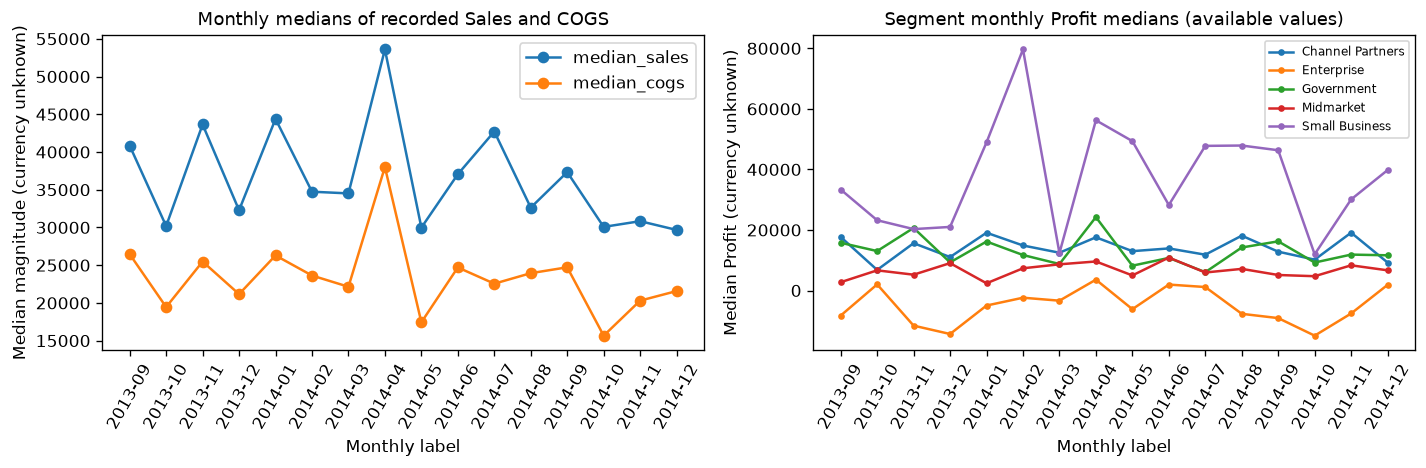

Pooled Sales median minimum / maximum months: 2014-12 2014-04
2013 contains four observed months; 2014 contains twelve. Their annual totals would not be like-for-like.


In [10]:
monthly=eda.groupby("period").agg(records=("sales","size"),median_sales=("sales","median"),median_gross_sales=("gross_sales","median"),median_cogs=("cogs","median"),median_profit=("profit","median"),profit_available=("profit","count"),negative_profit=("profit",lambda s:s.lt(0).sum()))
display(monthly)
segment_month=eda.groupby(["segment","period"]).agg(records=("sales","size"),median_sales=("sales","median"),median_profit=("profit","median"),profit_available=("profit","count"))
fig,axes=plt.subplots(1,2,figsize=(12,4))
for column in ["median_sales","median_cogs"]:
    axes[0].plot(monthly.index.astype(str),monthly[column],marker="o",label=column)
axes[0].set(title="Monthly medians of recorded Sales and COGS",xlabel="Monthly label",ylabel="Median magnitude (currency unknown)")
axes[0].legend();axes[0].tick_params(axis="x",rotation=60)
for segment in segment_profile.index:
    group=segment_month.loc[segment]
    axes[1].plot(group.index.astype(str),group.median_profit,marker=".",label=segment)
axes[1].set(title="Segment monthly Profit medians (available values)",xlabel="Monthly label",ylabel="Median Profit (currency unknown)")
axes[1].legend(fontsize=7);axes[1].tick_params(axis="x",rotation=60)
show_figure(fig)
print("Pooled Sales median minimum / maximum months:",monthly.median_sales.idxmin(),monthly.median_sales.idxmax())
print("2013 contains four observed months; 2014 contains twelve. Their annual totals would not be like-for-like.")

**Observed period behavior:** pooled median Sales ranges from **29,670.00 in December 2014** to **53,594.10 in April 2014**. The sequence fluctuates rather than supporting a simple steady trend. Short, compositionally uneven histories and unknown currency prevent translating this pattern into company growth.

## 10. Growth Analysis

**Company growth is not estimable.** Neither same-company linkage nor currency consistency across periods is established. The file also has repeated segment/country/product/discount-band/month combinations. Country or product cannot substitute for company identity.

No revenue, asset, income, or company-growth percentage is calculated. This avoids presenting changes in sample composition or unknown currency as financial growth. Section 9 provides descriptive monthly profiles instead. Before future growth calculations, establish an entity-period grain, matching currency/basis, consecutive periods, prior-value availability, and zero/near-zero denominator rules. Negative prior profit requires special interpretation; a percentage change would not automatically indicate improvement. The following continuity diagnostics concern categories only and do not authorize a company-growth interpretation.

In [11]:
continuity=[]
for segment,group in eda.groupby("segment"):
    observed=pd.PeriodIndex(sorted(group.period.unique()),freq="M")
    continuity.append({"segment":segment,"observed_periods":len(observed),"missing_inside_observed_span":len(pd.period_range(observed.min(),observed.max(),freq="M").difference(observed)),"first_period_has_no_prior_in_extract":True})
display(pd.DataFrame(continuity))
print("Company growth calculations performed: none; company and currency linkage unavailable.")

,segment,observed_periods,missing_inside_observed_span,first_period_has_no_prior_in_extract
0,Channel Partners,16,0,True
1,Enterprise,16,0,True
2,Government,16,0,True
3,Midmarket,16,0,True
4,Small Business,16,0,True


Company growth calculations performed: none; company and currency linkage unavailable.


## 11. Financial Ratios — Exploratory Only

First test plausible arithmetic relationships on complete numeric rows: Units × Sale Price versus Gross Sales; Gross Sales − Discounts versus Sales; Sales − COGS versus Profit. These are **consistency checks**, not adjustments, authoritative definitions, or proof of currency equality. Residual tolerance is 0.011 source units to accommodate displayed two-decimal rounding and floating-point arithmetic. No residual is used to fill a placeholder.

Then explore two row-local ratios: **Profit / Sales** (reported-profit share of sales, not net-income margin) and **Discounts / Gross Sales** (discount share). Their compatibility is supported provisionally by headers and observed arithmetic, conditional on numerator and denominator representing compatible units/currency within a record. That assumption is not independently confirmed. Ratios are not declared currency-safe merely because they are dimensionless. No balance-sheet ratios are available.

Exclude unavailable numerators/denominators and denominators with absolute magnitude below 0.01 from the temporary ratio only. This near-zero guard is exploratory, not an approved business threshold. Keep the source rows and report exclusions.

In [12]:
identity_definitions={"Units × Sale Price = Gross Sales":(numeric.units*numeric.sale_price,numeric.gross_sales),"Gross Sales − Discounts = Sales":(numeric.gross_sales-numeric.discounts,numeric.sales),"Sales − COGS = Profit":(numeric.sales-numeric.cogs,numeric.profit)}
identity_rows=[];identity_residuals={}
for label,(left,right) in identity_definitions.items():
    available=left.notna() & right.notna()
    residual=left[available]-right[available]
    identity_residuals[label]=residual
    identity_rows.append({"relationship":label,"testable_rows":int(available.sum()),"untestable_rows":int((~available).sum()),"within_0_011":int(residual.abs().le(.011).sum()),"outside_tolerance":int(residual.abs().gt(.011).sum()),"maximum_absolute_residual":residual.abs().max()})
identities=pd.DataFrame(identity_rows).set_index("relationship")
display(identities)
ratios=pd.DataFrame(index=raw_df.index);ratio_audit=[]
for label,numerator,denominator in [("reported_profit_share","profit","sales"),("discount_share","discounts","gross_sales")]:
    valid=numeric[numerator].notna() & numeric[denominator].notna() & numeric[denominator].abs().ge(.01)
    ratios[label]=numeric[numerator].div(numeric[denominator]).where(valid)
    ratio_audit.append({"ratio":label,"valid_rows":int(valid.sum()),"unavailable_operand_rows":int((numeric[numerator].isna()|numeric[denominator].isna()).sum()),"zero_or_near_zero_denominator":int(numeric[denominator].abs().lt(.01).sum())})
display(pd.DataFrame(ratio_audit).set_index("ratio"))
display(ratios.describe(percentiles=[.01,.25,.5,.75,.99]).T)
ratio_context=eda[["segment","discount_band"]].join(ratios)
print("Reported-profit-share distribution by segment (conditional ratios):")
display(ratio_context.groupby("segment").reported_profit_share.agg(["count","median","min","max"]))
print("Discount share by original discount-band label; unavailable values retained as unavailable:")
display(ratio_context.groupby("discount_band").discount_share.agg(["count","median","min","max"]))

,testable_rows,untestable_rows,within_0_011,outside_tolerance,maximum_absolute_residual
relationship,,,,,
Units × Sale Price = Gross Sales,700,0,700,0,0.000000e+00
Gross Sales − Discounts = Sales,647,53,647,0,1.000000e-02
Sales − COGS = Profit,695,5,695,0,4.547474e-12


,valid_rows,unavailable_operand_rows,zero_or_near_zero_denominator
ratio,,,
reported_profit_share,695,5,0
discount_share,647,53,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
reported_profit_share,695.0,0.281017,0.233826,-0.129412,-0.129412,0.131944,0.233716,0.43501,0.75,0.75
discount_share,647.0,0.079335,0.042598,0.010000,0.010000,0.050000,0.080000,0.12000,0.15,0.15


Reported-profit-share distribution by segment (conditional ratios):


,count,median,min,max
segment,,,,
Channel Partners,100,0.731183,0.705882,0.750000
Enterprise,95,-0.021277,-0.129412,0.040000
Government,300,0.248120,0.126050,0.500000
Midmarket,100,0.275362,0.215686,0.333333
Small Business,100,0.094203,0.019608,0.166667


Discount share by original discount-band label; unavailable values retained as unavailable:


,count,median,min,max
discount_band,,,,
High,245,0.13,0.10,0.15
Low,160,0.02,0.01,0.04
Medium,242,0.07,0.05,0.09
None,0,NaN,NaN,NaN


**Observed arithmetic:** all **700** quantity × price checks, **647** gross-sales/discount/sales checks, and **695** sales/COGS/profit checks fall within 0.011. The largest gross-sales reconciliation difference is **0.01**, consistent with—but not proof of—a rounding convention. No record is adjusted.

**Conditional ratios:** available reported-profit shares range from **−12.94% to 75.00%**, with median **23.37%**; parsed discount shares range from **1% to 15%**, with median **8%**. High, Medium, and Low bands show respective observed ranges of **10–15%**, **5–9%**, and **1–4%**. The `None` band has no parsed Discounts values, so no zero rate is assigned. No denominator is zero or below the 0.01 guard. These remain exploratory ratios conditional on within-record unit compatibility.

## 12. Relationships Between Financial Measures

Pearson and Spearman correlations use only Sales, COGS, Profit, and Units; no identifiers or time labels are correlated. Pairwise sample counts accompany coefficients. Spearman is computed as Pearson correlation of average ranks within each complete pair. Observed accounting identities and shared factors can mechanically induce strong correlations; association is not causation or independent predictive evidence. Unknown currency and pooled category mixtures limit interpretation.

In [13]:
relationship_measures=["sales","cogs","profit","units"]
relation=numeric[relationship_measures]
pearson=relation.corr()
spearman=pd.DataFrame(index=relationship_measures,columns=relationship_measures,dtype=float)
pair_counts=pd.DataFrame(index=relationship_measures,columns=relationship_measures,dtype=int)
for first in relationship_measures:
    for second in relationship_measures:
        valid=relation[first].notna() & relation[second].notna()
        pair_counts.loc[first,second]=int(valid.sum())
        spearman.loc[first,second]=relation.loc[valid,first].rank(method="average").corr(relation.loc[valid,second].rank(method="average"))
print("Pair counts:");display(pair_counts)
print("Pearson:");display(pearson)
print("Spearman (complete pairs, average ranks):");display(spearman)
within_segment=[]
for segment,group in eda.groupby("segment"):
    valid=group.sales.notna() & group.profit.notna()
    within_segment.append({"segment":segment,"pairs":int(valid.sum()),"sales_profit_pearson":group.loc[valid,"sales"].corr(group.loc[valid,"profit"])})
display(pd.DataFrame(within_segment))
print("No causal or model-performance claim follows from these descriptive relationships.")

Pair counts:


,sales,cogs,profit,units
sales,700.0,700.0,695.0,700.0
cogs,700.0,700.0,695.0,700.0
profit,695.0,695.0,695.0,695.0
units,700.0,700.0,695.0,700.0


Pearson:


,sales,cogs,profit,units
sales,1.000000,0.992244,0.806879,0.326914
cogs,0.992244,1.000000,0.727498,0.331694
profit,0.806879,0.727498,1.000000,0.228564
units,0.326914,0.331694,0.228564,1.000000


Spearman (complete pairs, average ranks):


,sales,cogs,profit,units
sales,1.000000,0.971460,0.596490,0.375869
cogs,0.971460,1.000000,0.487835,0.364909
profit,0.596490,0.487835,1.000000,0.297028
units,0.375869,0.364909,0.297028,1.000000


,segment,pairs,sales_profit_pearson
0,Channel Partners,100,0.999175
1,Enterprise,95,-0.175584
2,Government,300,0.970630
3,Midmarket,100,0.960855
4,Small Business,100,0.758367


No causal or model-performance claim follows from these descriptive relationships.


**Observed relationship:** pooled Sales–COGS Pearson correlation is approximately **0.992**, while Sales–Profit is **0.807**. Within Enterprise, Sales–Profit correlation is approximately **−0.176** (95 available pairs), unlike the positive pooled relationship. Accounting identities, price regimes, and category mixture limit causal or independent predictive interpretation.

## 13. Missingness Patterns

Distinguish **raw missing values**, **unresolved numeric placeholders**, and **unrecognized formats**. The first baseline has no raw nulls. The temporary unavailable values are not new evidence that the source has nulls. Explore placeholder dependence on segment, country, product, discount band, and month, without imputation. Company-based missingness cannot be studied.

In [14]:
unavailable=numeric[["discounts","profit"]].isna()
missingness_tables={}
for field in ["segment","country","product","discount_band","period"]:
    grouped=unavailable.groupby(eda[field],dropna=False)
    table=grouped.sum().rename(columns={"discounts":"discounts_unavailable","profit":"profit_unavailable"})
    table.insert(0,"records",grouped.size())
    table["discounts_unavailable_percent"]=table.discounts_unavailable/table.records*100
    table["profit_unavailable_percent"]=table.profit_unavailable/table.records*100
    missingness_tables[field]=table
    print(field);display(table)
print("Context of unresolved Profit representations:")
display(raw_df.loc[numeric.profit.isna(),["Segment","Country"," Product "," Discount Band ","Date","  Sales "," COGS "," Profit "]])
placeholder_identity_check=pd.DataFrame({"records":[numeric.discounts.isna().sum(),numeric.profit.isna().sum()],"other_fields_equal_within_0_011":[int((numeric.gross_sales[numeric.discounts.isna()]-numeric.sales[numeric.discounts.isna()]).abs().le(.011).sum()),int((numeric.sales[numeric.profit.isna()]-numeric.cogs[numeric.profit.isna()]).abs().le(.011).sum())]},index=["Discounts dollar-dash","Profit dollar-dash"])
display(placeholder_identity_check)

segment


,records,discounts_unavailable,profit_unavailable,discounts_unavailable_percent,profit_unavailable_percent
segment,,,,,
Channel Partners,100,10,0,10.000000,0.0
Enterprise,100,6,5,6.000000,5.0
Government,300,20,0,6.666667,0.0
Midmarket,100,13,0,13.000000,0.0
Small Business,100,4,0,4.000000,0.0


country


,records,discounts_unavailable,profit_unavailable,discounts_unavailable_percent,profit_unavailable_percent
country,,,,,
Canada,140,12,0,8.571429,0.000000
France,140,9,1,6.428571,0.714286
Germany,140,16,1,11.428571,0.714286
Mexico,140,8,3,5.714286,2.142857
United States of America,140,8,0,5.714286,0.000000


product


...

period


,records,discounts_unavailable,profit_unavailable,discounts_unavailable_percent,profit_unavailable_percent
period,,,,,
2013-09,35,3,0,8.571429,0.000000
2013-10,70,2,0,2.857143,0.000000
2013-11,35,2,0,5.714286,0.000000
2013-12,35,1,0,2.857143,0.000000
2014-01,35,3,0,8.571429,0.000000
2014-02,35,5,0,14.285714,0.000000
2014-03,35,2,1,5.714286,2.857143
2014-04,35,3,1,8.571429,2.857143
2014-05,35,0,0,0.000000,0.000000


Context of unresolved Profit representations:


,Segment,Country,Product,Discount Band,Date,Sales,COGS,Profit
187,Enterprise,Mexico,Montana,Low,01/12/2014,"$1,36,560.00","$1,36,560.00",$-
189,Enterprise,Germany,Paseo,Low,01/03/2014,"$95,400.00","$95,400.00",$-
193,Enterprise,France,Paseo,Low,01/07/2014,"$3,58,560.00","$3,58,560.00",$-
200,Enterprise,Mexico,Paseo,Low,01/12/2014,"$1,36,560.00","$1,36,560.00",$-
209,Enterprise,Mexico,Amarilla,Low,01/04/2014,"$1,28,880.00","$1,28,880.00",$-


,records,other_fields_equal_within_0_011
Discounts dollar-dash,53,53
Profit dollar-dash,5,5


**Observed placeholder patterns:** all **53** Discounts dashes are in discount band `None`, and all **5** Profit dashes are in Enterprise / Low. Gross Sales equals Sales for all 53 Discounts-placeholder records, and Sales equals COGS for all 5 Profit-placeholder records within the stated tolerance.

**Interpretation boundary:** dependence on discount band and arithmetic equality elsewhere may support a hypothesis that dashes encode zero in some contexts. Neither establishes the source convention. Dashes remain unresolved, and no derived zero is substituted. Exact meaning needs a dictionary or source confirmation. Missingness is not declared random. Literal `None` is a discount-band label, not a null company/category.

## 14. Extreme Value Investigation

Inspect high Sales, high/low Profit, and measure-specific global Tukey fences (Q1 − 1.5 IQR, Q3 + 1.5 IQR). Compare Sales/Profit fences with **segment × sale-price** peers only where at least 30 available observations and positive IQR exist. These categories may describe pricing regimes; they are not companies or confirmed currency-homogeneous populations. Thirty is an exploratory coverage guard, not proof of adequacy.

No automatic outlier removal, anomaly label, error label, or fraud claim is made. Global versus peer disagreement shows sensitivity to comparison population. No within-company rule is possible.

,available,lower_fence,upper_fence,below_fence,above_fence,p01,p99
measure,,,,,,,
units,700,-1081.1875,4215.3125,0,4,256.880,3875.205
manufacturing_price,700,-362.5000,617.5000,0,0,3.000,260.000
sale_price,700,-420.0000,732.0000,0,0,7.000,350.000
gross_sales,700,-375058.1250,671474.8750,0,55,2520.000,1006950.000
discounts,647,-25561.3750,45431.6250,0,57,92.334,110350.350
sales,700,-351796.2500,628801.7500,0,53,2293.200,978321.750
cogs,700,-349686.2500,602783.7500,0,36,1230.000,748022.300
profit,695,-26842.9500,52549.7700,6,96,-24260.875,236716.000


,global_candidates_all,peer_eligible_rows,peer_candidates,global_only_within_eligible,peer_only
measure,,,,,
sales,53,700,5,53,5
profit,102,695,7,100,5


Five largest Sales — original raw strings and CSV indices


,Segment,Country,Product,Discount Band,Date,Units Sold,Sale Price,Sales,COGS,Profit
192,Government,United States of America,Paseo,Low,01/07/2014,"$3,450.00",$350.00,"$11,59,200.00","$8,97,000.00","$2,62,200.00"
405,Small Business,Canada,Montana,Medium,01/04/2014,"$3,802.50",$300.00,"$10,38,082.50","$9,50,625.00","$87,457.50"
423,Small Business,Canada,Velo,Medium,01/07/2014,"$3,793.50",$300.00,"$10,35,625.50","$9,48,375.00","$87,250.50"
124,Government,Germany,Velo,Low,01/10/2013,"$2,966.00",$350.00,"$10,17,338.00","$7,71,160.00","$2,46,178.00"
140,Government,Germany,Amarilla,Low,01/10/2013,"$2,966.00",$350.00,"$10,17,338.00","$7,71,160.00","$2,46,178.00"


Five lowest Profit — original raw strings and CSV indices


,Segment,Country,Product,Discount Band,Date,Units Sold,Sale Price,Sales,COGS,Profit
692,Enterprise,Canada,VTT,High,01/11/2013,"$2,954.00",$125.00,"$3,13,862.50","$3,54,480.00","$(40,617.50)"
667,Enterprise,Germany,Carretera,High,01/08/2014,"$2,767.00",$125.00,"$2,93,993.75","$3,32,040.00","$(38,046.25)"
659,Enterprise,United States of America,Amarilla,High,01/05/2014,"$2,844.00",$125.00,"$3,05,730.00","$3,41,280.00","$(35,550.00)"
631,Enterprise,Mexico,Carretera,High,01/12/2013,"$2,821.00",$125.00,"$3,03,257.50","$3,38,520.00","$(35,262.50)"
686,Enterprise,United States of America,Velo,High,01/12/2013,"$2,438.00",$125.00,"$2,59,037.50","$2,92,560.00","$(33,522.50)"


Five highest Profit — original raw strings and CSV indices


,Segment,Country,Product,Discount Band,Date,Units Sold,Sale Price,Sales,COGS,Profit
192,Government,United States of America,Paseo,Low,01/07/2014,"$3,450.00",$350.00,"$11,59,200.00","$8,97,000.00","$2,62,200.00"
45,Government,France,Amarilla,None,01/02/2014,"$2,750.00",$350.00,"$9,62,500.00","$7,15,000.00","$2,47,500.00"
124,Government,Germany,Velo,Low,01/10/2013,"$2,966.00",$350.00,"$10,17,338.00","$7,71,160.00","$2,46,178.00"
140,Government,Germany,Amarilla,Low,01/10/2013,"$2,966.00",$350.00,"$10,17,338.00","$7,71,160.00","$2,46,178.00"
125,Government,Germany,Velo,Low,01/10/2014,"$2,877.00",$350.00,"$9,86,811.00","$7,48,020.00","$2,38,791.00"


Negative Profit context by segment and discount band:


negative_profit_records
segment    discount_band                         
Enterprise High                                33
           Medium                              25

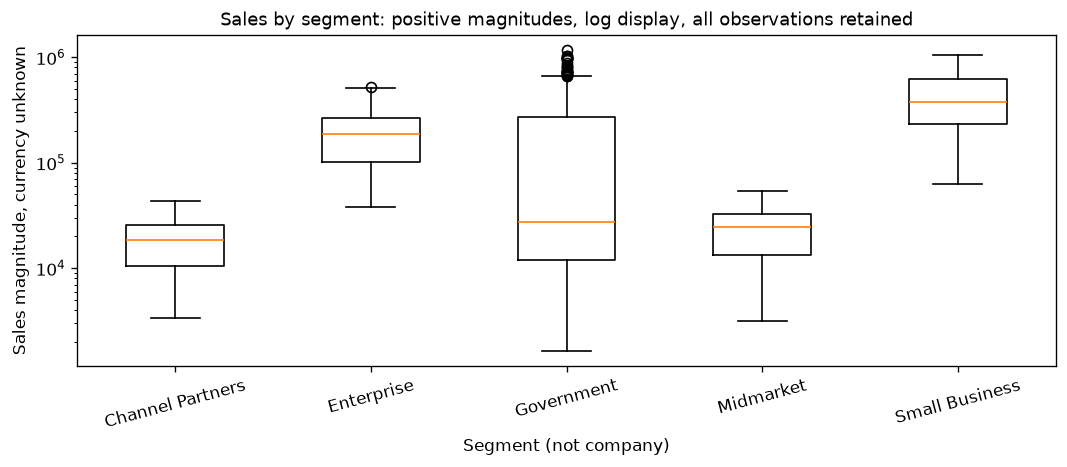

In [15]:
extreme_global=[]
for measure in numeric:
    s=numeric[measure];q1,q3=s.quantile([.25,.75]);iqr=q3-q1
    extreme_global.append({"measure":measure,"available":s.count(),"lower_fence":q1-1.5*iqr,"upper_fence":q3+1.5*iqr,"below_fence":int(s.lt(q1-1.5*iqr).sum()),"above_fence":int(s.gt(q3+1.5*iqr).sum()),"p01":s.quantile(.01),"p99":s.quantile(.99)})
display(pd.DataFrame(extreme_global).set_index("measure"))
peer_extreme_rows=[];peer_flags={}
for measure in ["sales","profit"]:
    s=eda[measure];q1,q3=s.quantile([.25,.75]);global_flag=s.lt(q1-1.5*(q3-q1))|s.gt(q3+1.5*(q3-q1))
    grouped=eda.groupby(["segment","sale_price"])[measure]
    n=grouped.transform("count");p1=grouped.transform(lambda x:x.quantile(.25));p3=grouped.transform(lambda x:x.quantile(.75))
    eligible=n.ge(30)&p3.gt(p1)&s.notna()
    flag=eligible&(s.lt(p1-1.5*(p3-p1))|s.gt(p3+1.5*(p3-p1)))
    peer_flags[measure]=(global_flag,eligible,flag)
    peer_extreme_rows.append({"measure":measure,"global_candidates_all":int(global_flag.sum()),"peer_eligible_rows":int(eligible.sum()),"peer_candidates":int(flag.sum()),"global_only_within_eligible":int((eligible&global_flag&~flag).sum()),"peer_only":int((flag&~global_flag).sum())})
peer_extremes=pd.DataFrame(peer_extreme_rows).set_index("measure");display(peer_extremes)
context_columns=["Segment","Country"," Product "," Discount Band ","Date"," Units Sold "," Sale Price ","  Sales "," COGS "," Profit "]
for description,indices in [("Five largest Sales",numeric.sales.nlargest(5).index),("Five lowest Profit",numeric.profit.nsmallest(5).index),("Five highest Profit",numeric.profit.nlargest(5).index)]:
    print(description,"— original raw strings and CSV indices")
    display(raw_df.loc[indices,context_columns])
print("Negative Profit context by segment and discount band:")
display(eda.loc[numeric.profit.lt(0)].groupby(["segment","discount_band"]).size().rename("negative_profit_records").to_frame())
fig,ax=plt.subplots(figsize=(9,4))
labels=segment_profile.index.tolist()
ax.boxplot([numeric.sales[eda.segment.eq(label)] for label in labels],tick_labels=labels,showfliers=True)
ax.set_yscale("log")
ax.set(title="Sales by segment: positive magnitudes, log display, all observations retained",xlabel="Segment (not company)",ylabel="Sales magnitude, currency unknown")
ax.tick_params(axis="x",rotation=15);show_figure(fig)

**Observed candidate sensitivity:** the global Sales fence selects **53** records, while segment × sale-price fences select **5** among all 700 eligible records; these two Sales sets do not overlap. For Profit, the global rule selects **102**, versus **7** peer candidates among 695 available records. These are different descriptive screens, not competing accuracy estimates. All 58 negative Profit values fall in Enterprise, split between **33 High** and **25 Medium** discount-band records. Context matters; none is removed.

## 15. Potential Peer Groups for Anomaly Detection

Candidate peers must match the available sales domain. Measure-specific comparisons are preferable to treating all eight measures as interchangeable. Segment and sale price may describe different pricing populations; product and discount band add context where coverage permits. Country is geography, not a currency grouping or company identity. All choices remain conditional on comparable units and record grain.

In [16]:
peer_options=[["segment"],["segment","sale_price"],["segment","product"],["segment","discount_band"],["segment","country","product"],["segment","sale_price","period"]]
peer_sizes=[]
for keys in peer_options:
    sizes=eda.groupby(keys,dropna=False).size()
    peer_sizes.append({"grouping":" × ".join(keys),"groups":len(sizes),"min_records":sizes.min(),"median_records":sizes.median(),"max_records":sizes.max(),"groups_ge30":int(sizes.ge(30).sum()),"records_in_groups_ge30":int(sizes[sizes.ge(30)].sum())})
peer_feasibility=pd.DataFrame(peer_sizes).set_index("grouping");display(peer_feasibility)
print("These counts use all rows; available Profit/Discounts samples are smaller.")

,groups,min_records,median_records,max_records,groups_ge30,records_in_groups_ge30
grouping,,,,,,
segment,5,100,100.0,300,5,700
segment × sale_price,7,100,100.0,100,7,700
segment × product,30,12,15.0,88,7,336
segment × discount_band,20,4,29.0,119,10,527
segment × country × product,150,2,4.0,18,0,0
segment × sale_price × period,112,5,5.0,10,0,0


These counts use all rows; available Profit/Discounts samples are smaller.


**Observed feasibility:** segment × sale price creates **7 groups of 100 records**. Adding month creates 112 groups with only **5–10 records each**, making monthly peer fences unstable. Segment/country/product groups have **2–18 records** and no group reaches the exploratory 30-record guard. The broader pricing groups are more feasible for investigation, conditional on comparable currency/units and source grain.

Cross-company detection and within-company history are **unsupported**. Potential future work could investigate sales-record peers, row-local ratio behavior, and deviations from empirically supported arithmetic relationships. Period-over-period company-change detection remains blocked by entity/currency ambiguity. Adding month to every peer group can fragment a short sample. No labels, validated detection thresholds, models, or performance estimates are produced.

## 16. Multi-Currency Readiness

- **Confirmed currency:** none. The exact schema contains no currency code or currency-name field; no global currency is documented in the inventory's local sources.
- **Observed representation:** `$` appears in every supplied measure string, including Units Sold. This is formatting evidence, not proof of USD, CAD, a common currency, or even a monetary interpretation for Units Sold.
- **Inferred currency:** none assigned. Country names are not used to infer currency. Arithmetic consistency cannot establish currency denomination.
- **Unknown:** whether a common reporting currency was used, whether currency differs across rows, and the original transaction versus reporting currency. Currency variation cannot be measured when currency is absent.

Future data would conceptually need to preserve original amount/string, original currency, entity and transaction/reporting period, and—only if conversion is later authorized—source/target currency, rate, rate date, rate source, conversion convention, and converted amount separately. This is a documentation requirement, not a schema or FX implementation. No currency conversion or base-currency designation is performed.

In [17]:
currency_columns=[c for c in raw_df.columns if re.search(r"currency|devise|moeda|ISO.?4217",c,re.I)]
print("Explicit currency columns:",currency_columns)
display(format_report[["dollar_symbol","other_currency_symbol","percent_symbol"]])
print("Confirmed ISO currency assignments: none. FX conversions performed: none.")

Explicit currency columns: []


,dollar_symbol,other_currency_symbol,percent_symbol
units,700,0,0
manufacturing_price,700,0,0
sale_price,700,0,0
gross_sales,700,0,0
discounts,700,0,0
sales,700,0,0
cogs,700,0,0
profit,700,0,0


Confirmed ISO currency assignments: none. FX conversions performed: none.


## 17. Key EDA Findings

The evidence table uses preceding outputs and retains the distinction between recorded numeric patterns and verified business facts.

In [18]:
findings=pd.DataFrame([
["Sales-domain dataset, no company identity","700 rows × 16 columns; no company name/ID, assets, liabilities, equity, or cash","Company comparisons and growth cannot be claimed"],
["Temporary parsing coverage",f"{int(parsing_report.successful.sum())} parsed measure cells; {int(parsing_report.unresolved_dash.sum())} unresolved dashes; {int(parsing_report.unrecognized_format.sum())} unrecognized formats","Confirm conventions before a cleaning plan"],
["Monthly labels with uneven counts",f"16 consecutive labels; {monthly_counts.min()}–{monthly_counts.max()} rows/month","Do not compare annual totals or infer entity growth"],
["Sales magnitude skew",f"Mean {numeric.sales.mean():,.2f}, median {numeric.sales.median():,.2f}, skewness {numeric.sales.skew():.3f}","Context-sensitive summaries and peers"],
["Signed Profit observations",f"{numeric.profit.lt(0).sum()} negative values; range {numeric.profit.min():,.2f} to {numeric.profit.max():,.2f}","Investigate context; do not delete losses automatically"],
["Arithmetic relationships",f"{int(identities.within_0_011.sum())}/{int(identities.testable_rows.sum())} testable relationship checks within tolerance","Supports conditional row-local ratios; does not establish definitions/currency"],
["Global and peer rules differ",f"Sales global candidates {peer_extremes.loc['sales','global_candidates_all']}; peer candidates {peer_extremes.loc['sales','peer_candidates']} among {peer_extremes.loc['sales','peer_eligible_rows']} eligible rows","Population and threshold choices need validation"],
["Placeholder patterns",f"Discounts {numeric.discounts.isna().sum()}; Profit {numeric.profit.isna().sum()}; raw null cells 0","Separate unresolved representations from missing source values"],
["Currency unconfirmed","No currency column or documented global denomination; dollar formatting in all measures","No economically comparable monetary totals or FX without metadata"],
],columns=["Finding","Evidence","Potential Relevance"])
display(findings)

,Finding,Evidence,Potential Relevance
0,"Sales-domain dataset, no company identity","700 rows × 16 columns; no company name/ID, assets, liabilities, equity, or cash",Company comparisons and growth cannot be claimed
1,Temporary parsing coverage,5542 parsed measure cells; 58 unresolved dashes; 0 unrecognized formats,Confirm conventions before a cleaning plan
2,Monthly labels with uneven counts,16 consecutive labels; 35–70 rows/month,Do not compare annual totals or infer entity growth
3,Sales magnitude skew,"Mean 169,609.07, median 35,540.20, skewness 1.696",Context-sensitive summaries and peers
4,Signed Profit observations,"58 negative values; range -40,617.50 to 262,200.00",Investigate context; do not delete losses automatically
5,Arithmetic relationships,2042/2042 testable relationship checks within tolerance,Supports conditional row-local ratios; does not establish definitions/currency
6,Global and peer rules differ,Sales global candidates 53; peer candidates 5 among 700 eligible rows,Population and threshold choices need validation
7,Placeholder patterns,Discounts 53; Profit 5; raw null cells 0,Separate unresolved representations from missing source values
8,Currency unconfirmed,No currency column or documented global denomination; dollar formatting in all measures,No economically comparable monetary totals or FX without metadata


## 18. Data Quality Issues Identified for Later Investigation

### Confirmed Issue

- Eight financial/quantity columns are stored as formatted strings; numeric use requires an explicit parsing interpretation. Formatting includes whitespace, different comma grouping, parentheses, and dollar signs even on Units Sold.
- There are 58 unresolved measure cells (53 Discounts, 5 Profit) under the preserved parsing policy. They are non-null strings, not verified missing amounts or zeros.
- Company identification, currency metadata, source provenance, and a stable source-level record ID are absent from the available evidence. These are completeness/interpretability limitations, not established errors in the values.

### Requires Investigation

- Meaning of dollar-dash placeholders, source sign/rounding conventions, fractional Units Sold, and whether amount fields share units/currency within and across records.
- Exact row aggregation and the price-dependent candidate key's stability; 12 repeated five-field combinations do not prove duplicate business events.
- Extreme and negative amounts, global/peer disagreement, category mix, and temporal coverage/sampling. No extreme is labeled erroneous.
- Any arithmetic residual outside the explicitly displayed tolerance needs source review; no correction or balancing entry is generated.

### Expected / Structural Behavior

- Monthly labels may be intended period markers, rather than transaction dates; full source-period completeness remains unverified.
- Literal `None` is a discount-band category. Category-linked placeholders may reflect a structural display convention, but that explanation remains a hypothesis until documented.
- Discrete prices and differing segment/product profiles are observed category structure, not inherently defects.

No full duplicate rows, raw nulls, failed date parses, or unrecognized amount formats were found. These checks do not establish complete business validity. Nothing is cleaned or removed.

## 19. Implications for Financial Manager AI

| Capability | Assessment retained | Effect of detailed EDA |
|---|---|---|
| Financial Data Analysis | Suitable | Strengthened for exploratory sales/cost/profit questions through parsing audits, conditional arithmetic checks, and category/period profiles. Company-level and currency-comparable financial statements remain unsupported. |
| Financial Anomaly Detection | Potentially Suitable | More concrete candidates for sales-record peers and ratio/relationship review; unknown entity/currency/grain and limited coverage still prevent validated anomaly claims. |
| Cash Flow Forecast | Partial | No material change. Monthly sales context exists, but sales/profit are not verified cash movements; no cash accounts, balances, settlement schedule, or confirmed entity history appeared. |
| Budget Variance | Inadequate | No material change. There are no budget amounts, versions, or matching planned-versus-actual basis. |

Accounts Payable and Financial Document RAG remain **Inadequate**. No new obligations or document corpus is introduced. Inventory labels require no revision; this EDA sharpens their scope and limitations without editing earlier notebooks.

## 20. Preliminary EDA Conclusions

**Observations:** the file is a 700-record sales dataset with eight text-formatted measures and 16 consecutive monthly labels. It does not identify companies. Dates agree with supplied month/year fields, but category-combination coverage and row counts vary. Parsed sales/cost/profit magnitudes are skewed, and Profit includes negatives. Arithmetic checks, conditional ratios, category profiles, pairwise correlations, and global/peer candidate comparisons provide descriptive evidence. Only 2 of 150 segment/country/product combinations cover all 16 months. All 58 negative Profit values are in Enterprise. All 2,042 testable arithmetic checks agree within tolerance. The global Sales fence selects 53 records while pricing-peer fences select 5, with no overlap. Conditional ratio ranges and sample sizes appear in sections 11–17. Raw data contains no nulls or complete duplicates; 58 measure tokens remain unresolved. Currency is unknown.

**Unsupported company questions:** company coverage/size, differences between companies, company financial trajectories, and within-company growth cannot be inferred from country, product, or segment. Balance-sheet ratios are unavailable. Cross-record monetary comparisons are not established as economically comparable.

**Hypotheses:** some dollar-dash representations may encode zero, and segment/price/discount context may explain apparent extremes and changing period medians. Arithmetic regularities support provisional row-local reported-profit and discount shares, conditional on compatible units. None of these hypotheses proves currency, source definitions, causation, or anomalies.

**Unresolved:** authoritative provenance and dictionary; company/entity scope; currency denomination and reporting basis; exact aggregation grain and stable record identity; placeholder meanings; within-record ratio compatibility; completeness and comparability across periods; and reference evidence for evaluating future anomaly candidates.

**Next decision only:** review these findings before authorizing any cleaning plan or additional data acquisition. Do not automatically fill dashes, remove losses/extremes, create company identifiers, convert currency, or build models. No schema, FX functionality, ML, RAG, or application work starts here.

### Final Validation

The final cell verifies source preservation and reconciles exploratory outputs. Temporary numeric representations and ratios are never written back to the source or exported as a cleaned dataset.

In [19]:
pd.testing.assert_frame_equal(raw_df,raw_snapshot)
pd.testing.assert_frame_equal(raw_df,pd.read_csv(raw_path))
assert raw_df.columns.tolist()==expected_columns
assert len(eda)==len(raw_df)==len(numeric)==len(ratios)
assert numeric.index.equals(raw_df.index)
for path,digest in original_hashes.items():
    assert hashlib.sha256(Path(path).read_bytes()).hexdigest()==digest,path
assert monthly.records.sum()==700
assert monthly.profit_available.sum()==numeric.profit.count()
assert numeric.notna().sum().sum()==parsing_report.successful.sum()
assert parsing_report.successful.sum()+parsing_report.unsuccessful_populated.sum()==raw_df[list(measure_map.values())].notna().sum().sum()
for field in ["segment","country","product"]:
    assert eda.groupby(field).size().sum()==700
    assert np.isclose(eda.groupby(field).sales.sum().sum(),numeric.sales.sum(),rtol=1e-12)
assert ratios.notna().sum().to_dict()=={"reported_profit_share":695,"discount_share":647}
assert not np.isinf(ratios.to_numpy()).any()
assert len(missing_periods)==0
assert not plt.get_fignums()
print("PASS: raw files, original DataFrame values/types, and both prior notebooks preserved.")
print("PASS: baseline, parsing counts, category/period counts, numeric sums, and ratio coverage reconcile.")
print("Temporary numeric/date/ratio/candidate objects remain in notebook memory only.")
print("No permanent cleaning, imputation, FX conversion, ML training, production features, schema, or application implementation performed.")

PASS: raw files, original DataFrame values/types, and both prior notebooks preserved.
PASS: baseline, parsing counts, category/period counts, numeric sums, and ratio coverage reconcile.
Temporary numeric/date/ratio/candidate objects remain in notebook memory only.
No permanent cleaning, imputation, FX conversion, ML training, production features, schema, or application implementation performed.
